# PCI on a dynamical SIR model with policies

This notebook applies **proximate causal influence (PCI)** to a Bayesian SIR
epidemiological model with two interacting non-pharmaceutical policies, lockdown and
mask-wearing. The setup mirrors the chirho tutorial on
[explainable reasoning in dynamical systems][chirho-sir], which uses chirho's
`SearchForExplanation` handler to compute classical actual-cause probabilities. We
keep the same model and the same query, but replace the explanatory machinery with
the PCI thin-search sampler from `pci.explanation`, which produces a continuous
responsibility score that decomposes into necessity and sufficiency contributions.

We will see that PCI recovers the qualitative finding of the chirho tutorial —
lockdown is the dominant cause of excessive overshoot, despite both policies
appearing roughly symmetric under but-for analysis — and that PCI extends naturally
to dynamical settings with continuous outcomes.

[chirho-sir]: https://basisresearch.github.io/chirho/explainable_sir.html

In [1]:
import os
import sys
from itertools import chain, combinations

import matplotlib.pyplot as plt
import pandas as pd
import pyro
import seaborn as sns
import torch
from chirho.interventional.handlers import do
from chirho.observational.handlers import condition
from IPython.display import Image, display

smoke_test = "CI" in os.environ
import os
import pickle
from time import time

import pyro.distributions as dist
from loguru import logger

from pci.explanation.regime import condition_on_interventional_regime
from pci.explanation.scores import abs_diff_score
from pci.explanation.searchable import SearchableModel
from pci.explanation.thin_search import ThinSearchSampler
from pci.tools.find_root import find_repo_root

root = find_repo_root()
results_dir = os.path.join(root, "docs/source/dynamical_benchmark")

print(f"Results will be saved to {results_dir}")

# first allow debug for illustration
logger.remove()
logger.add(sys.stderr, level="DEBUG")


# TODO clean up for CI etc.
runtime_limit = 0.25 if smoke_test else 60  # in minutes
num_worlds_at_site = 2 if smoke_test else 10  #
runtime_limit_seconds = runtime_limit * 60

# change to True if in fact intending to run the experiments anew
fresh_run = True

import numbers
import os
from typing import Tuple, TypeVar, Union, Optional, Callable
import math

import matplotlib.pyplot as plt
import pandas as pd
import pyro.distributions as dist
from pyro.distributions import constraints
import seaborn as sns
import torch
from pyro.infer import Predictive

import pyro
from chirho.counterfactual.handlers.counterfactual import MultiWorldCounterfactual
from chirho.dynamical.handlers.interruption import StaticEvent
from chirho.dynamical.handlers.solver import TorchDiffEq
from chirho.dynamical.handlers.trajectory import LogTrajectory
from chirho.dynamical.ops import Dynamics, State, on, simulate
from chirho.explainable.handlers import SearchForExplanation
from chirho.explainable.handlers.components import ExtractSupports
from chirho.indexed.ops import IndexSet, gather
from chirho.interventional.ops import Intervention, intervene
from chirho.observational.handlers import condition

R = Union[numbers.Real, torch.Tensor]
S = TypeVar("S")
T = TypeVar("T")


sns.set_style("white")

seed = 123
pyro.clear_param_store()
pyro.set_rng_seed(seed)


# Paper-grade matplotlib defaults
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "savefig.dpi": 160,
    "savefig.bbox": "tight",
})

fig_dir = os.path.join(root, "docs/source/sir_benchmark")

Results will be saved to /home/rafal/s76projects/explainable_paper/docs/source/dynamical_benchmark


## SIR model with policies

We use the standard SIR dynamics

$$\dot S = -\beta S I, \qquad \dot I = \beta S I - \gamma I, \qquad \dot R = \gamma I,$$

with a parameterised variant `SIRDynamicsPolicies` that introduces an intervention
strength $l \in [0, 1]$, modulating the transmission rate to $(1 - l)\beta_0$. With
no policies active the model reduces to the unparameterised dynamics.

**Assumptions.** All dynamics are deterministic; stochasticity enters only through
priors over $\beta$ and $\gamma$. The structural model is taken as correctly
specified, and no unobserved confounders are assumed between parameters.

**Outcome and threshold.** The outcome is the *overshoot* — the peak-to-final $S$
gap of the simulated trajectory. Without interventions on a 100-person population the
deterministic overshoot is $\approx 15.1$, well below the $24$-person threshold we
treat as the undesirable outcome.

In [2]:
# dS = - beta . SI
# dI = beta * SI - gamma * I
# dR = gamma * I

class SIRDynamics(pyro.nn.PyroModule):
    def __init__(self, beta, gamma):
        super().__init__()
        self.beta = beta
        self.gamma = gamma

    def forward(self, X: State[torch.Tensor]):
        dX: State[torch.Tensor] = dict()
        dX["S"] = -self.beta * X["S"] * X["I"]
        dX["I"] = self.beta * X["S"] * X["I"] - self.gamma * X["I"]
        dX["R"] = self.gamma * X["I"]

        return dX


# l is a parameter describing the strength of the intervening policies
# it is a value between 0 and 1, and (1-l) is the fraction of the original unintervened beta
class SIRDynamicsPolicies(SIRDynamics):
    def __init__(self, beta0, gamma):
        super().__init__(beta0, gamma)
        self.beta0 = beta0

    def forward(self, X: State[torch.Tensor]):
        self.beta = (1 - X["l"]) * self.beta0
        dX = super().forward(X)
        dX["l"] = torch.zeros_like(X["l"])
        return dX

In [3]:
# Computing overshoot in a simple SIR model without interventions
# note it's below the desired threshold

total_population = 100
init_state = dict(S=torch.tensor(99.0), I=torch.tensor(1.0), R=torch.tensor(0.0))
assert init_state["S"] + init_state["I"] + init_state["R"] == total_population

start_time = torch.tensor(0.0)
end_time = torch.tensor(12.0)
step_size = torch.tensor(0.1)
logging_times = torch.arange(start_time, end_time, step_size)
init_state_lockdown = dict(**init_state, l=torch.tensor(0.0))

# We now simulate from the SIR model
beta_true = torch.tensor([0.03])
gamma_true = torch.tensor([0.5])
sir_true = SIRDynamics(beta_true, gamma_true)
with TorchDiffEq(), LogTrajectory(logging_times) as lt:
    simulate(sir_true, init_state, start_time, end_time)

sir_true_traj = lt.trajectory


def get_overshoot(trajectory):
    t_max = torch.argmax(trajectory["I"].squeeze())
    S_peak = torch.max(trajectory["S"].squeeze()[t_max]) / total_population
    S_final = trajectory["S"].squeeze()[-1] / total_population
    return (S_peak - S_final).item()


print(get_overshoot(sir_true_traj))

0.15116800367832184


### Bayesian SIR with priors

We add Beta priors: $\beta \sim \mathrm{Beta}(18, 600)$ and
$\gamma \sim \mathrm{Beta}(1600, 1600)$, centred near $0.03$ and $0.5$
respectively.

### Policies and asymmetric efficiencies

Two policies, each with prior probability $1/2$, can be enacted: lockdown at $t=1$
and masking at $t=1.5$. Their efficiencies interact asymmetrically:

- Lockdown alone has efficiency $0.6$.
- Masking efficiency depends on lockdown: $0.1$ under lockdown (fewer interactions
  for masks to block) versus $0.45$ on its own.
- The joint efficiency is the clamped sum, capped at $0.95$.

Interventions are dispatched via `MaskedStaticIntervention` to avoid trace
conflicts. `overshoot_query` reads the peak-to-final $S$ gap from the logged
trajectory and flags
$\mathrm{os\_too\_high} = \mathbb{1}[\mathrm{overshoot} > 24]$.

In [4]:
# Defining a Bayesian SIR model where we have priors over beta and gamma distributions

def bayesian_sir(base_model=SIRDynamics) -> Dynamics[torch.Tensor]:
    beta = pyro.sample("beta", dist.Beta(18, 600))
    gamma = pyro.sample("gamma", dist.Beta(1600, 1600))
    sir = base_model(beta, gamma)
    return sir


def simulated_bayesian_sir(
    init_state, start_time, logging_times, base_model=SIRDynamics
) -> State[torch.Tensor]:
    sir = bayesian_sir(base_model)

    with TorchDiffEq(), LogTrajectory(logging_times, is_traced=True) as lt:
        simulate(sir, init_state, start_time, logging_times[-1])
    return lt.trajectory

In [5]:
# a utility function
# allowing for interventions on a dynamical system
# within another model
# to avoid conflicts arising from repeated sites in the trace

def MaskedStaticIntervention(time: R, intervention: Intervention[State[T]]):

    @on(StaticEvent(time))
    def callback(
        dynamics: Dynamics[T], state: State[T]
    ) -> Tuple[Dynamics[T], State[T]]:

        with pyro.poutine.block():
            return dynamics, intervene(state, intervention)

    return callback

In [6]:
# Defining the policy model

overshoot_threshold = 24
lockdown_time = torch.tensor(1.0)
mask_time = torch.tensor(1.5)

def policy_model() -> State[torch.Tensor]:

    lockdown = pyro.sample("lockdown", dist.Bernoulli(torch.tensor(0.5)))
    mask = pyro.sample("mask", dist.Bernoulli(torch.tensor(0.5)))

    lockdown_efficiency = pyro.deterministic(
        "lockdown_efficiency", torch.tensor(0.6) * lockdown, event_dim=0
    )

    mask_efficiency = pyro.deterministic(
        "mask_efficiency", (0.1 * lockdown + 0.45 * (1 - lockdown)) * mask, event_dim=0
    )

    joint_efficiency = pyro.deterministic(
        "joint_efficiency",
        torch.clamp(lockdown_efficiency + mask_efficiency, 0, 0.95),
        event_dim=0,
    )

    lockdown_sir = bayesian_sir(SIRDynamicsPolicies)
    with LogTrajectory(logging_times, is_traced=True) as lt:
        with TorchDiffEq():
            with MaskedStaticIntervention(lockdown_time, dict(l=lockdown_efficiency)):
                with MaskedStaticIntervention(mask_time, dict(l=joint_efficiency)):
                    simulate(
                        lockdown_sir, init_state_lockdown, start_time, logging_times[-1]
                    )

    return lt.trajectory

def overshoot_query(trajectory: State[torch.Tensor]) -> Tuple[torch.Tensor, torch.Tensor]:

    t_max = torch.max(trajectory["I"], dim=-1).indices
    S_peaks = pyro.ops.indexing.Vindex(trajectory["S"])[..., t_max]
    overshoot = pyro.deterministic(
        "overshoot", S_peaks - trajectory["S"][..., -1], event_dim=0
    )
    os_too_high = pyro.deterministic(
        "os_too_high",
        (overshoot > overshoot_threshold).clone().detach().float(),
        event_dim=0,
    )

    return overshoot, os_too_high

def overshoot_model():
    trajectory = policy_model()
    return overshoot_query(trajectory)

## But-for analysis

We first run the classical but-for query: condition on each pair of policy decisions
(`(0,0)`, `(1,1)`, `(0,1)`, `(1,0)`) and draw $100$ predictives from each. Each
scenario yields a marginal distribution over overshoot, summarised by its mean and
by $\Pr(\mathrm{overshoot} > 24)$.

In [7]:
num_samples = 100

# conditioning (as opposed to intervening) is sufficient for
# propagating the changes, as the decisions are upstream from ds

# no interventions
overshoot_model_none = condition(
    overshoot_model, {"lockdown": torch.tensor(0.0), "mask": torch.tensor(0.0)}
)
unintervened_predictive = Predictive(
    overshoot_model_none, num_samples=num_samples, parallel=True
)
unintervened_samples = unintervened_predictive()

# both interventions
overshoot_model_all = condition(
    overshoot_model, {"lockdown": torch.tensor(1.0), "mask": torch.tensor(1.0)}
)
intervened_predictive = Predictive(
    overshoot_model_all, num_samples=num_samples, parallel=True
)
intervened_samples = intervened_predictive()

overshoot_model_mask = condition(
    overshoot_model, {"lockdown": torch.tensor(0.0), "mask": torch.tensor(1.0)}
)
mask_predictive = Predictive(overshoot_model_mask, num_samples=num_samples, parallel=True)
mask_samples = mask_predictive()

overshoot_model_lockdown = condition(
    overshoot_model, {"lockdown": torch.tensor(1.0), "mask": torch.tensor(0.0)}
)
lockdown_predictive = Predictive(
    overshoot_model_lockdown, num_samples=num_samples, parallel=True
)
lockdown_samples = lockdown_predictive()

predictive = Predictive(overshoot_model, num_samples=num_samples, parallel=True)
samples = predictive()

print("Variables in the model:", samples.keys())


Variables in the model: dict_keys(['lockdown', 'mask', 'beta', 'gamma', 'lockdown_efficiency', 'mask_efficiency', 'joint_efficiency', 'S', 'I', 'R', 'l', 'overshoot', 'os_too_high'])


Saved /home/rafal/s76projects/explainable_paper/docs/source/sir_benchmark/sir_butfor.png


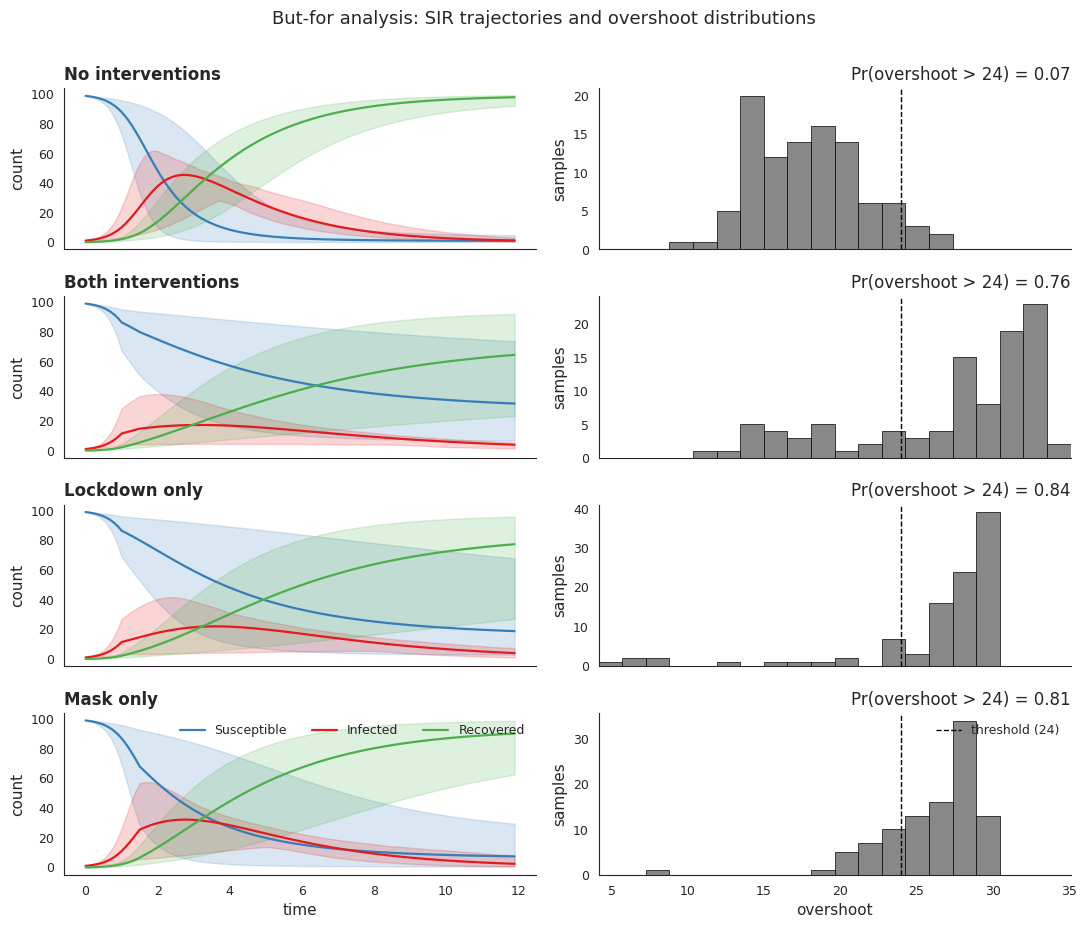

In [8]:
# Figure 1: but-for analysis — SIR trajectories and overshoot distributions
# 4 scenarios x 2 panels (trajectory on left, overshoot histogram on right).
# The "stochastic" prior-mixture case is dropped from this figure for clarity.

# SIR palette (color-blind safe).
sir_colors = {"S": "#377eb8", "I": "#e41a1c", "R": "#4daf4a"}


def _add_traj(preds, ax, color, label):
    sns.lineplot(
        x=logging_times,
        y=preds.mean(dim=0).squeeze().tolist(),
        ax=ax,
        label=label,
        color=color,
        linewidth=1.6,
    )
    ax.fill_between(
        logging_times,
        torch.quantile(preds, 0.025, dim=0).squeeze(),
        torch.quantile(preds, 0.975, dim=0).squeeze(),
        alpha=0.18,
        color=color,
    )


scenarios = [
    ("No interventions", unintervened_samples),
    ("Both interventions", intervened_samples),
    ("Lockdown only", lockdown_samples),
    ("Mask only", mask_samples),
]

n_rows = len(scenarios)
fig, axs = plt.subplots(n_rows, 2, figsize=(11, 2.3 * n_rows), sharex="col")

# common overshoot x-range across the histogram column
all_overshoot = torch.cat(
    [s["overshoot"].squeeze().flatten() for _, s in scenarios]
).detach().cpu().numpy()
hist_lo, hist_hi = float(all_overshoot.min()), float(all_overshoot.max())
hist_pad = 0.05 * (hist_hi - hist_lo + 1e-9)
hist_lo -= hist_pad
hist_hi += hist_pad

for i, (label, samples_i) in enumerate(scenarios):
    ax_traj = axs[i, 0]
    _add_traj(samples_i["S"], ax_traj, sir_colors["S"], "Susceptible")
    _add_traj(samples_i["I"], ax_traj, sir_colors["I"], "Infected")
    _add_traj(samples_i["R"], ax_traj, sir_colors["R"], "Recovered")
    ax_traj.set_title(label, loc="left", fontweight="bold")
    ax_traj.set_ylabel("count")
    if i < n_rows - 1 and ax_traj.get_legend() is not None:
        ax_traj.get_legend().remove()
    else:
        ax_traj.legend(loc="upper right", ncol=3, frameon=False)
    if i == n_rows - 1:
        ax_traj.set_xlabel("time")

    ax_hist = axs[i, 1]
    o = samples_i["overshoot"].squeeze().detach().cpu().numpy()
    pr_too_high = float(samples_i["os_too_high"].squeeze().float().mean().item())
    ax_hist.hist(o, bins=20, range=(hist_lo, hist_hi), color="#888888",
                  edgecolor="black", linewidth=0.5)
    ax_hist.axvline(overshoot_threshold, color="black", linestyle="--", linewidth=1.0,
                     label=f"threshold ({overshoot_threshold})")
    ax_hist.set_title(
        f"Pr(overshoot > {overshoot_threshold}) = {pr_too_high:.2f}",
        loc="right",
    )
    ax_hist.set_xlim(hist_lo, hist_hi)
    ax_hist.set_ylabel("samples")
    if i == n_rows - 1:
        ax_hist.set_xlabel("overshoot")
        ax_hist.legend(loc="upper right", frameon=False)

fig.suptitle(
    "But-for analysis: SIR trajectories and overshoot distributions",
    fontsize=13,
    y=1.005,
)
plt.tight_layout()
sns.despine()

if not smoke_test:
    os.makedirs(fig_dir, exist_ok=True)
    fig.savefig(os.path.join(fig_dir, "sir_butfor.png"))
    print(f"Saved {os.path.join(fig_dir, 'sir_butfor.png')}")

The four panels reveal a counter-intuitive pattern. With no intervention,
$\Pr(\mathrm{overshoot} > 24) \approx 0.07$ and the mean overshoot is $17.9$.
Both policies together push the probability to $\approx 0.67$. But applying
*either* policy alone produces a *higher* probability than the joint case:
lockdown-only gives $\approx 0.82$ and mask-only $\approx 0.87$. Stochastic
policies (the prior-mixture case) sit in between at $\approx 0.61$.

The mechanism is the asymmetric joint efficiency. Combining the two policies caps
the transmission reduction at $0.95$, but neither policy alone reaches that cap, and
mask-only is comparatively weak — yet under lockdown, masking's contribution is
dampened to $0.1$, so adding masking to lockdown only marginally improves on
lockdown-alone, and the joint case may underperform mask-only depending on prior
draws of $\beta, \gamma$.

But-for analysis cannot disentangle this kind of context dependence — it treats each
policy as a binary cause and reports an aggregate effect, with no way to express
that lockdown's causal contribution depends on whether masking is in force. That is
the gap PCI fills.

## Causal explanations using PCI thin search

Where the chirho tutorial uses `SearchForExplanation` to estimate the probability
that a candidate cause is the *actual* cause, we use the PCI thin-search sampler.
Both procedures explore the same family of *interventional regimes* — joint
assignments of antecedents (where to intervene), witnesses (where to condition on
factual values), and outcome — but PCI scores each regime with a continuous
$|y^* - y_{\mathrm{nec}}| - |y^* - y_{\mathrm{suff}}|$ statistic and averages
across regimes. The $\mathrm{nec}$ term rewards regimes where removing the suspect
moves the outcome *away* from the factual value $y^*$; the $\mathrm{suff}$ term
rewards regimes where fixing the suspect at its factual value keeps the outcome
*close* to $y^*$.

The suspects are **lockdown** and **mask**, with **lockdown_efficiency**,
**mask_efficiency** and **joint_efficiency** as additional sites of interest the
sampler may use as witnesses. The factual world fixes both policies on
($\mathrm{lockdown}=1, \mathrm{mask}=1$), with $y^* = \mathrm{overshoot}$ read
from the same trajectory. For each suspect the sampler draws $2{,}500$ regimes that
intervene on that suspect as antecedent while leaving it out of the witness set, and
we score the resulting sufficiency/necessity outcome pair against $y^*$.

Because the factual world is the *both-policies-on* scenario, $y^\star \approx 33$
for this seed and these fixed efficiencies — well above the $24$-overshoot
threshold. Most sampled regimes intervene to remove at least one policy, so the
necessity- and sufficiency-side overshoot distributions in the figures below sit
between the threshold and $y^\star$ (typically in the high-$20$s). The cross-hair
at $y^\star$ is therefore not a "central" reference but the high-overshoot anchor
against which removal- and retention-style interventions are scored.

In [9]:
def searchable_overshoot_model(
    kwargs_iterable=[
        {"observations_dict": None, "n_size": 1},
        dict(),
        dict(),
    ]
):
    batch_size = int(kwargs_iterable[0]["n_size"])
    observations_dict = kwargs_iterable[0].get("observations_dict", None)

    obs_data = None
    if observations_dict is not None:
        obs_data = observations_dict.get("continuous", {}) | observations_dict.get(
            "categorical", {}
        )

    # ensure tensors have shape [..., batch, padding, event] = [batch, 1, 1]
    def _expand_scalar(x: torch.Tensor) -> torch.Tensor:
        return x.expand(batch_size, 1, 1)

    init_state_batched = {
        "S": _expand_scalar(init_state["S"]),
        "I": _expand_scalar(init_state["I"]),
        "R": _expand_scalar(init_state["R"]),
        "l": _expand_scalar(torch.tensor(0.0)),
    }

    if obs_data is None:
        _condition_cm = None
    else:
        _condition_cm = condition(data=obs_data)

    if _condition_cm is None:
        # sample categorical suspects
        logits01 = torch.ones(batch_size, 1, 1, 2)
        lockdown = pyro.sample("lockdown", dist.Categorical(logits=logits01))
        mask = pyro.sample("mask", dist.Categorical(logits=logits01))

        lockdown_f = lockdown.float()
        mask_f = mask.float()

        lockdown_efficiency = pyro.deterministic(
            "lockdown_efficiency", torch.tensor(0.6) * lockdown_f, event_dim=0
        )

        mask_efficiency = pyro.deterministic(
            "mask_efficiency",
            (0.1 * lockdown_f + 0.45 * (1 - lockdown_f)) * mask_f,
            event_dim=0,
        )

        joint_efficiency = pyro.deterministic(
            "joint_efficiency",
            torch.clamp(lockdown_efficiency + mask_efficiency, 0, 0.95),
            event_dim=0,
        )

        lockdown_sir = bayesian_sir(SIRDynamicsPolicies)
        with LogTrajectory(logging_times, is_traced=True) as lt:
            with TorchDiffEq():
                with MaskedStaticIntervention(lockdown_time, dict(l=lockdown_efficiency)):
                    with MaskedStaticIntervention(mask_time, dict(l=joint_efficiency)):
                        simulate(
                            lockdown_sir,
                            init_state_batched,
                            start_time,
                            logging_times[-1],
                        )

        trajectory = lt.trajectory
        return overshoot_query(trajectory)

    else:
        with _condition_cm:
            # sample categorical suspects
            logits01 = torch.ones(batch_size, 1, 1, 2)
            lockdown = pyro.sample("lockdown", dist.Categorical(logits=logits01))
            mask = pyro.sample("mask", dist.Categorical(logits=logits01))

            lockdown_f = lockdown.float()
            mask_f = mask.float()

            lockdown_efficiency = pyro.deterministic(
                "lockdown_efficiency", torch.tensor(0.6) * lockdown_f, event_dim=0
            )

            mask_efficiency = pyro.deterministic(
                "mask_efficiency",
                (0.1 * lockdown_f + 0.45 * (1 - lockdown_f)) * mask_f,
                event_dim=0,
            )

            joint_efficiency = pyro.deterministic(
                "joint_efficiency",
                torch.clamp(lockdown_efficiency + mask_efficiency, 0, 0.95),
                event_dim=0,
            )

            lockdown_sir = bayesian_sir(SIRDynamicsPolicies)
            with LogTrajectory(logging_times, is_traced=True) as lt:
                with TorchDiffEq():
                    with MaskedStaticIntervention(
                        lockdown_time, dict(l=lockdown_efficiency)
                    ):
                        with MaskedStaticIntervention(mask_time, dict(l=joint_efficiency)):
                            simulate(
                                lockdown_sir,
                                init_state_batched,
                                start_time,
                                logging_times[-1],
                            )

            trajectory = lt.trajectory
            return overshoot_query(trajectory)


suspects = ["lockdown", "mask"]
sites_of_interest = suspects + ["lockdown_efficiency", "mask_efficiency", "joint_efficiency"]

searchable_model = SearchableModel(
    structured_model=searchable_overshoot_model,
    sites_of_interest=sites_of_interest,
    suspects=suspects,
    outcome_variable="overshoot",
)

# a single factual world (batch_size = 1)
# NOTE: if you edit obs_dict, also flip fresh_run=True (or change seed) so the
# cache is not silently reused.
obs_dict = {
    "continuous": {
        "lockdown_efficiency": torch.tensor([[[0.6]]]),
        "mask_efficiency": torch.tensor([[[0.1]]]),
        "joint_efficiency": torch.tensor([[[0.7]]]),
    },
    "categorical": {
        "lockdown": torch.tensor([[[1]]], dtype=torch.long),
        "mask": torch.tensor([[[1]]], dtype=torch.long),
    },
}

sampler = ThinSearchSampler(
    structured_model=searchable_model,
    conditioned_alternatives=True,
    factual_exclusion=True,
    max_antecedents=4,
    max_witnesses_dropped=4,
)

num_search_samples = 5 if smoke_test else 2_500

cache_path = os.path.join(
    results_dir, f"search_single_n{num_search_samples}_seed{seed}.pkl"
)

if (not smoke_test) and (not fresh_run) and os.path.exists(cache_path):
    with open(cache_path, "rb") as f:
        search_results, factual_overshoot = pickle.load(f)
    print(f"Loaded cache {cache_path}")
else:
    search_results = sampler.sample(obs_dict, num_samples=num_search_samples)

    # Factual outcome y* for scoring (computed under the factual lockdown/mask values)
    with torch.no_grad():
        with pyro.poutine.trace() as tr_factual:
            searchable_overshoot_model(
                kwargs_iterable=[
                    {"observations_dict": obs_dict, "n_size": 1},
                    {},
                    {},
                ]
            )

    factual_overshoot = tr_factual.trace.nodes["overshoot"]["value"].detach()

    if not smoke_test:
        os.makedirs(results_dir, exist_ok=True)
        with open(cache_path, "wb") as f:
            pickle.dump((search_results, factual_overshoot), f)
        print(f"Wrote cache {cache_path}")

# Continuous-outcome scoring, following search_query.ipynb
suspect_score_means = {}
for suspect_name in suspects:
    suspect_sample = condition_on_interventional_regime(
        results_dictionary=search_results,
        reference_variable_names=[suspect_name],
        antecedent_regimes={suspect_name: True},
        witness_regimes={suspect_name: False},
    )

    overshoot_suff = suspect_sample["regime_sufficiency"]["overshoot"]
    overshoot_nec = suspect_sample["regime_necessity"]["overshoot"]

    scores = abs_diff_score(
        suff_outcomes=overshoot_suff,
        nec_outcomes=overshoot_nec,
        factual_outcomes=factual_overshoot,
    )

    suspect_score_means[suspect_name] = {
        key: torch.nanmean(value).item() for key, value in scores.items()
    }

print(suspect_score_means)


  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 1/2500 [00:00<11:52,  3.51it/s]

  0%|          | 2/2500 [00:00<11:46,  3.54it/s]

  0%|          | 3/2500 [00:00<10:36,  3.92it/s]

  0%|          | 4/2500 [00:01<11:44,  3.54it/s]

...

100%|█████████▉| 2498/2500 [12:37<00:00,  3.25it/s]

100%|█████████▉| 2499/2500 [12:38<00:00,  3.11it/s]

100%|██████████| 2500/2500 [12:38<00:00,  3.10it/s]

100%|██████████| 2500/2500 [12:38<00:00,  3.30it/s]

Wrote cache /home/rafal/s76projects/explainable_paper/docs/source/dynamical_benchmark/search_single_n2500_seed123.pkl
{'lockdown': {'suff': -6.578051567077637, 'nec': 8.120043754577637, 'total': 1.541993260383606}, 'mask': {'suff': -6.6729230880737305, 'nec': 7.430387020111084, 'total': 0.7574641108512878}}


PCI assigns lockdown roughly $2.0\times$ the responsibility of mask:

| suspect  | $\overline{|y^*-y_{\mathrm{nec}}|}$ | $-\overline{|y^*-y_{\mathrm{suff}}|}$ | total |
|----------|------|------|------|
| lockdown | 8.12 | $-6.58$ | **1.54** |
| mask     | 7.43 | $-6.67$ | **0.76** |

The gap is driven by the necessity term: removing lockdown moves overshoot further
from $y^*$ than removing mask does ($8.12$ vs $7.43$ in mean absolute distance),
while the sufficiency terms are within $0.1$ of each other. This is consistent with
the but-for finding that either policy *alone* is roughly equally bad — what
distinguishes the two suspects is that lockdown's removal *under context*
(witnesses held at factual) pulls the world further from the factual outcome than
mask's removal does.

In [ ]:
# Figure 2: per-suspect distributions under PCI thin search.
# Rows = suspects; col 0 = overshoot under suff/nec interventions; col 1 = score.

NEC_COLOR = "#d62728"   # red
SUFF_COLOR = "#1f77b4"  # blue
SCORE_COLOR = "#7b1fa2" # purple


def _flatten_drop_nans(x: torch.Tensor) -> torch.Tensor:
    x = x.detach().cpu().flatten()
    return x[~torch.isnan(x)]


factual_overshoot_scalar = float(_flatten_drop_nans(factual_overshoot)[0].item())

n_rows = len(suspects)
fig, axs = plt.subplots(n_rows, 2, figsize=(11, 3.0 * n_rows))
if n_rows == 1:
    axs = axs.reshape(1, 2)

# common x-range for the suff/nec overshoot histograms (col 0)
all_outcome_vals = []
score_vals_per_suspect = {}
for suspect_name in suspects:
    ss = condition_on_interventional_regime(
        results_dictionary=search_results,
        reference_variable_names=[suspect_name],
        antecedent_regimes={suspect_name: True},
        witness_regimes={suspect_name: False},
    )
    suff_vals = _flatten_drop_nans(ss["regime_sufficiency"]["overshoot"]).numpy()
    nec_vals = _flatten_drop_nans(ss["regime_necessity"]["overshoot"]).numpy()
    all_outcome_vals.append(suff_vals)
    all_outcome_vals.append(nec_vals)
    sc = abs_diff_score(
        suff_outcomes=ss["regime_sufficiency"]["overshoot"],
        nec_outcomes=ss["regime_necessity"]["overshoot"],
        factual_outcomes=factual_overshoot,
    )
    score_vals_per_suspect[suspect_name] = (
        suff_vals,
        nec_vals,
        _flatten_drop_nans(sc["total"]).numpy(),
    )

import numpy as np
all_outcome = np.concatenate([v for v in all_outcome_vals if v.size > 0]) if all_outcome_vals else np.array([0.0, 1.0])
out_lo = float(np.nanpercentile(all_outcome, 1)) if all_outcome.size > 1 else 0.0
out_hi = float(np.nanpercentile(all_outcome, 99)) if all_outcome.size > 1 else 1.0
out_pad = 0.05 * (out_hi - out_lo + 1e-9)
out_lo -= out_pad
out_hi += out_pad

all_scores = np.concatenate([v[2] for v in score_vals_per_suspect.values() if v[2].size > 0]) if score_vals_per_suspect else np.array([-1.0, 1.0])
score_lo = float(np.nanpercentile(all_scores, 1)) if all_scores.size > 1 else -1.0
score_hi = float(np.nanpercentile(all_scores, 99)) if all_scores.size > 1 else 1.0
score_pad = 0.05 * (score_hi - score_lo + 1e-9)
score_lo -= score_pad
score_hi += score_pad

for i, suspect_name in enumerate(suspects):
    suff_vals, nec_vals, total_scores = score_vals_per_suspect[suspect_name]

    # --- col 0: outcome distributions (suff vs nec)
    ax0 = axs[i, 0]
    if suff_vals.size > 0:
        sns.histplot(
            suff_vals,
            bins=25,
            binrange=(out_lo, out_hi),
            color=SUFF_COLOR,
            alpha=0.55,
            stat="density",
            label="sufficiency (suspect at factual)",
            ax=ax0,
        )
    if nec_vals.size > 0:
        sns.histplot(
            nec_vals,
            bins=25,
            binrange=(out_lo, out_hi),
            color=NEC_COLOR,
            alpha=0.55,
            stat="density",
            label="necessity (suspect removed)",
            ax=ax0,
        )
    ax0.axvline(factual_overshoot_scalar, color="black", linestyle="-",
                 linewidth=1.6, label=r"factual $y^*$ (lockdown$=$mask$=1$)")
    ax0.axvline(overshoot_threshold, color="black", linestyle="--",
                 linewidth=1.0, alpha=0.7,
                 label=f"threshold ({overshoot_threshold})")
    ax0.set_xlim(out_lo, out_hi)
    ax0.set_title(f"Suspect: {suspect_name}", loc="left", fontweight="bold")
    ax0.set_xlabel("overshoot" if i == n_rows - 1 else "")
    ax0.set_ylabel("density")
    if i == 0:
        ax0.legend(loc="upper right", fontsize=8, frameon=False)
    else:
        legend = ax0.get_legend()
        if legend is not None:
            legend.remove()

    # --- col 1: total score distribution, with positive region shaded
    ax1 = axs[i, 1]
    if total_scores.size > 0:
        sns.histplot(
            total_scores,
            bins=25,
            binrange=(score_lo, score_hi),
            color=SCORE_COLOR,
            alpha=0.75,
            stat="density",
            ax=ax1,
        )
    ax1.axvline(0, color="black", linestyle="-", linewidth=1.0)
    # shade x>0 region (PCI total > 0 is "real cause" territory)
    ax1.axvspan(0, score_hi, alpha=0.06, color=SCORE_COLOR)
    ax1.set_xlim(score_lo, score_hi)
    ax1.set_title(f"Total score (suspect: {suspect_name})", loc="left", fontweight="bold")
    ax1.set_xlabel(r"$|y^* - y_{\mathrm{nec}}| - |y^* - y_{\mathrm{suff}}|$"
                    if i == n_rows - 1 else "")
    ax1.set_ylabel("density")

fig.suptitle(
    "PCI thin search: per-suspect outcome and score distributions",
    fontsize=13, y=1.005,
)
plt.tight_layout()
sns.despine()

if not smoke_test:
    os.makedirs(fig_dir, exist_ok=True)
    fig.savefig(os.path.join(fig_dir, "sir_pci_distributions.png"))
    print(f"Saved {os.path.join(fig_dir, 'sir_pci_distributions.png')}")

### Joint necessity-sufficiency heatmap

For each suspect we plot every sampled interventional regime as a point in the plane,
with the *necessity-side* overshoot $y_{\mathrm{nec}}$ on the horizontal axis (the
overshoot computed when the suspect is intervened to its alternative value, with the
antecedent set intervened and the witness set held at factual) and the *sufficiency-side*
overshoot $y_{\mathrm{suff}}$ on the vertical axis (suspect held at factual, antecedent
set intervened, witnesses at factual). The KDE shading shows the density of regimes; a
faint scatter underneath shows individual regime locations.

Two reference markers anchor the figure:

- The dotted red cross-hair is the **factual outcome** $y^\star$, computed at the factual
  policy values $\mathrm{lockdown}=\mathrm{mask}=1$ — the both-policies-on world. For this
  seed $y^\star\approx 33$, well above the $24$-overshoot threshold (the dash-dot blue
  cross-hair); most sampled regimes intervene to remove at least one policy, so the cloud
  sits between the threshold and $y^\star$, below $y^\star$ on both axes.
- The dashed black diagonal is $y_{\mathrm{nec}}=y_{\mathrm{suff}}$. It is a useful but
  partial reference: a regime above it has $y_{\mathrm{suff}} > y_{\mathrm{nec}}$, i.e.
  "fixing the suspect at factual keeps overshoot higher than removing it does," which
  resembles the cause pattern *only* when $y^\star$ sits at or above the cloud (as it
  does here).

What actually controls the PCI score is the geometry relative to the cross-hair, not the
diagonal: a regime contributes positively to the total iff
$|y^\star-y_{\mathrm{nec}}|>|y^\star-y_{\mathrm{suff}}|$ — i.e. it sits *further from
the red cross-hair along the $x$-axis than along the $y$-axis*. With $y^\star$ pinned at
the high-overshoot anchor, that condition becomes "$y_{\mathrm{nec}}$ is pulled
noticeably lower than $y_{\mathrm{suff}}$," which is what we want to see on the
necessity side.

Comparing the two panels: **lockdown** has mass shifted left of the diagonal — removing
lockdown drives $y_{\mathrm{nec}}$ well below $y^\star$ while $y_{\mathrm{suff}}$ stays
close to it. **Mask** has mass closer to the diagonal — removing mask doesn't pull
$y_{\mathrm{nec}}$ as far from $y^\star$. That asymmetry is the visual signature of the
$8.12$-vs-$7.43$ necessity-term gap reported in the table above.

In [ ]:
import numpy as np
from matplotlib.patches import Polygon as _MplPolygon, Patch

# Figure 3: joint necessity-sufficiency outcome density per suspect.
# Each point in the underlying scatter is one sampled regime. Faint green shading
# marks the region where the regime contributes positively to the PCI total
# (|y* - y_nec| > |y* - y_suff|); the X marker is the median (y_nec, y_suff)
# per panel.

per_suspect_pairs = {}
combined = []
for suspect_name in suspects:
    sample = condition_on_interventional_regime(
        results_dictionary=search_results,
        reference_variable_names=[suspect_name],
        antecedent_regimes={suspect_name: True},
        witness_regimes={suspect_name: False},
    )
    nec_t = sample["regime_necessity"]["overshoot"].detach().cpu().flatten()
    suff_t = sample["regime_sufficiency"]["overshoot"].detach().cpu().flatten()
    keep = ~(torch.isnan(nec_t) | torch.isnan(suff_t))
    nec_vals = nec_t[keep].numpy()
    suff_vals = suff_t[keep].numpy()
    per_suspect_pairs[suspect_name] = (nec_vals, suff_vals)
    combined.append(nec_vals)
    combined.append(suff_vals)

combined_arr = np.concatenate(combined) if combined else np.array([0.0, 1.0])
if combined_arr.size > 1:
    lo = float(np.nanpercentile(combined_arr, 1))
    hi = float(np.nanpercentile(combined_arr, 99))
else:
    lo, hi = 0.0, 1.0
pad = 0.05 * (hi - lo + 1e-9)
lo, hi = lo - pad, hi + pad


def _score_positive_polys(y_star, lo_, hi_):
    """Polygons inside [lo_, hi_]^2 where |y_star - x| > |y_star - y|.

    Boundaries are the two diagonals through (y_star, y_star): y = x and
    y = 2*y_star - x. The score>0 region is the union of the left wedge
    (x < y_star) and the right wedge (x > y_star) cut by those lines.
    """
    polys = []
    # Left wedge: above y=x, below y=2y*-x, x<y*.
    left = [(lo_, lo_), (y_star, y_star)]
    if 2 * y_star - lo_ <= hi_:
        left.append((lo_, 2 * y_star - lo_))
    else:
        x_top = 2 * y_star - hi_
        if x_top >= lo_:
            left.append((x_top, hi_))
            left.append((lo_, hi_))
        else:
            left.append((lo_, hi_))
    polys.append(left)
    # Right wedge: below y=x, above y=2y*-x, x>y*.
    right = [(y_star, y_star), (hi_, hi_)]
    if 2 * y_star - hi_ >= lo_:
        right.append((hi_, 2 * y_star - hi_))
    else:
        x_bot = 2 * y_star - lo_
        if x_bot <= hi_:
            right.append((hi_, lo_))
            right.append((x_bot, lo_))
        else:
            right.append((hi_, lo_))
    polys.append(right)
    return polys


WEDGE_COLOR = "#4daf4a"  # green: faintly marks score>0 region

fig, axs = plt.subplots(
    1, len(suspects), figsize=(5.5 * len(suspects), 5), sharex=True, sharey=True
)
if len(suspects) == 1:
    axs = [axs]

for i, suspect_name in enumerate(suspects):
    nec_vals, suff_vals = per_suspect_pairs[suspect_name]
    ax = axs[i]

    # Shade score-positive wedges first so KDE sits on top.
    for poly_pts in _score_positive_polys(factual_overshoot_scalar, lo, hi):
        ax.add_patch(
            _MplPolygon(
                poly_pts,
                closed=True,
                facecolor=WEDGE_COLOR,
                alpha=0.08,
                edgecolor="none",
                zorder=0,
            )
        )

    if nec_vals.size > 5:
        sns.kdeplot(
            x=nec_vals,
            y=suff_vals,
            fill=True,
            levels=8,
            thresh=0.04,
            cmap="rocket_r",
            ax=ax,
        )
        # underlay a faint scatter so individual regimes are visible too
        ax.scatter(nec_vals, suff_vals, s=4, color="black", alpha=0.05, linewidths=0)
    ax.plot([lo, hi], [lo, hi], color="black", linestyle="--", alpha=0.55,
            linewidth=1.0, label=r"$y_{\mathrm{nec}} = y_{\mathrm{suff}}$")
    ax.axvline(factual_overshoot_scalar, color="#d62728", linestyle=":",
               linewidth=1.4, label=r"factual $y^*$ (lockdown$=$mask$=1$)")
    ax.axhline(factual_overshoot_scalar, color="#d62728", linestyle=":",
               linewidth=1.4)
    ax.axvline(overshoot_threshold, color="#1f77b4", linestyle="-.",
               linewidth=1.2, alpha=0.85,
               label=f"threshold ({overshoot_threshold})")
    ax.axhline(overshoot_threshold, color="#1f77b4", linestyle="-.",
               linewidth=1.2, alpha=0.85)

    # Median (centroid) marker per panel.
    if nec_vals.size > 0:
        median_nec = float(np.median(nec_vals))
        median_suff = float(np.median(suff_vals))
        ax.plot(
            median_nec, median_suff,
            marker="X", color="black",
            markersize=11, markeredgecolor="white", markeredgewidth=1.5,
            linestyle="none", zorder=12,
            label="median regime" if i == 0 else None,
        )

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel(r"overshoot under necessity intervention ($y_{\mathrm{nec}}$)")
    if i == 0:
        ax.set_ylabel(r"overshoot under sufficiency intervention ($y_{\mathrm{suff}}$)")
    ax.set_title(f"Suspect: {suspect_name}", loc="left", fontweight="bold")
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        wedge_patch = Patch(
            facecolor=WEDGE_COLOR, alpha=0.35, edgecolor="none",
            label=r"score $>0$ region",
        )
        handles.append(wedge_patch)
        labels.append(wedge_patch.get_label())
        ax.legend(handles, labels, loc="lower right", fontsize=9, framealpha=0.9)

fig.suptitle(
    "PCI thin search: joint necessity-sufficiency overshoot density",
    fontsize=13, y=1.02,
)
plt.tight_layout()
sns.despine()

if not smoke_test:
    os.makedirs(fig_dir, exist_ok=True)
    fig.savefig(os.path.join(fig_dir, "sir_heatmap.png"))
    print(f"Saved {os.path.join(fig_dir, 'sir_heatmap.png')}")

The visible shift of the lockdown density off the diagonal is what the necessity term
in the score is averaging: the further-left a regime sits relative to the red cross-hair,
the more it contributes to the total.

### Robustness across factual worlds

So far we have fixed a single factual world. To check robustness, we now sample a
batch of factual worlds from the prior, run thin search on each, and report the
mean total score per world.

  0%|          | 0/50 [00:00<?, ?it/s]

  2%|▏         | 1/50 [00:00<00:20,  2.42it/s]

  4%|▍         | 2/50 [00:00<00:20,  2.35it/s]

  6%|▌         | 3/50 [00:01<00:20,  2.32it/s]

  8%|▊         | 4/50 [00:01<00:20,  2.28it/s]

...

 98%|█████████▊| 49/50 [00:21<00:00,  2.32it/s]

100%|██████████| 50/50 [00:21<00:00,  2.40it/s]

100%|██████████| 50/50 [00:21<00:00,  2.31it/s]

Wrote cache /home/rafal/s76projects/explainable_paper/docs/source/dynamical_benchmark/search_many_worlds10_n50_seed123.pkl


Saved /home/rafal/s76projects/explainable_paper/docs/source/sir_benchmark/sir_many_worlds.png


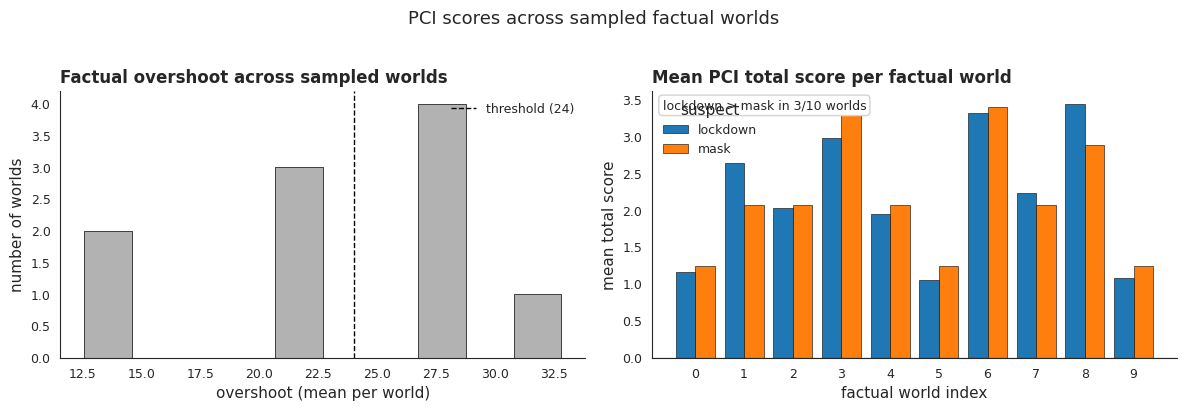

In [12]:
# Figure 4 generation cell: factual-world batch search + visualization.
# This cell runs the heavier compute (cached); the visualization at the bottom
# now uses paired bars so suspects can be compared directly per world.


def _as_long(x: torch.Tensor) -> torch.Tensor:
    return x.detach().long()


def _as_float(x: torch.Tensor) -> torch.Tensor:
    return x.detach().float()


num_factual_worlds = num_worlds_at_site
num_search_samples_many = 5 if smoke_test else 50

cache_path_many = os.path.join(
    results_dir,
    f"search_many_worlds{num_factual_worlds}_n{num_search_samples_many}_seed{seed}.pkl",
)

if (not smoke_test) and (not fresh_run) and os.path.exists(cache_path_many):
    with open(cache_path_many, "rb") as f:
        (
            search_results_many,
            factual_overshoot_many,
            obs_dict_many,
            factual_lockdown_many,
            factual_mask_many,
            factual_lockdown_eff_many,
            factual_mask_eff_many,
            factual_joint_eff_many,
        ) = pickle.load(f)
    print(f"Loaded cache {cache_path_many}")
else:
    with torch.no_grad():
        with pyro.poutine.trace() as tr_worlds:
            searchable_overshoot_model(
                kwargs_iterable=[
                    {"observations_dict": None, "n_size": num_factual_worlds},
                    {},
                    {},
                ]
            )

    factual_lockdown_many = _as_long(tr_worlds.trace.nodes["lockdown"]["value"])
    factual_mask_many = _as_long(tr_worlds.trace.nodes["mask"]["value"])

    factual_lockdown_eff_many = _as_float(
        tr_worlds.trace.nodes["lockdown_efficiency"]["value"]
    )
    factual_mask_eff_many = _as_float(tr_worlds.trace.nodes["mask_efficiency"]["value"])
    factual_joint_eff_many = _as_float(tr_worlds.trace.nodes["joint_efficiency"]["value"])

    factual_overshoot_many = _as_float(tr_worlds.trace.nodes["overshoot"]["value"])

    obs_dict_many = {
        "continuous": {
            "lockdown_efficiency": factual_lockdown_eff_many,
            "mask_efficiency": factual_mask_eff_many,
            "joint_efficiency": factual_joint_eff_many,
        },
        "categorical": {
            "lockdown": factual_lockdown_many,
            "mask": factual_mask_many,
        },
    }

    sampler_many = ThinSearchSampler(
        structured_model=searchable_model,
        conditioned_alternatives=True,
        factual_exclusion=True,
        max_antecedents=4,
        max_witnesses_dropped=4,
    )

    search_results_many = sampler_many.sample(
        obs_dict_many, num_samples=num_search_samples_many
    )

    if not smoke_test:
        os.makedirs(results_dir, exist_ok=True)
        with open(cache_path_many, "wb") as f:
            pickle.dump(
                (
                    search_results_many,
                    factual_overshoot_many,
                    obs_dict_many,
                    factual_lockdown_many,
                    factual_mask_many,
                    factual_lockdown_eff_many,
                    factual_mask_eff_many,
                    factual_joint_eff_many,
                ),
                f,
            )
        print(f"Wrote cache {cache_path_many}")


def _mean_total_per_world(scores_total: torch.Tensor) -> torch.Tensor:
    t = scores_total.detach().cpu()
    t = t.reshape(t.shape[0], t.shape[1], -1)
    return torch.nanmean(t, dim=(0, 2))


# Compute mean PCI total per world per suspect.
total_per_world_per_suspect = {}
for suspect_name in suspects:
    ss = condition_on_interventional_regime(
        results_dictionary=search_results_many,
        reference_variable_names=[suspect_name],
        antecedent_regimes={suspect_name: True},
        witness_regimes={suspect_name: False},
    )
    sc = abs_diff_score(
        suff_outcomes=ss["regime_sufficiency"]["overshoot"],
        nec_outcomes=ss["regime_necessity"]["overshoot"],
        factual_outcomes=factual_overshoot_many,
    )
    total_per_world_per_suspect[suspect_name] = _mean_total_per_world(sc["total"]).numpy()

factual_over_flat = (
    factual_overshoot_many.detach().cpu().reshape(num_factual_worlds, -1).mean(dim=1)
)

import numpy as np

SUSPECT_COLORS = {"lockdown": "#1f77b4", "mask": "#ff7f0e"}

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# panel 1: factual overshoot distribution across worlds
sns.histplot(
    factual_over_flat.numpy(),
    bins=min(20, max(num_factual_worlds, 4)),
    color="#999999",
    edgecolor="black",
    linewidth=0.5,
    ax=axs[0],
)
axs[0].axvline(overshoot_threshold, color="black", linestyle="--",
                linewidth=1.0, label=f"threshold ({overshoot_threshold})")
axs[0].set_title("Factual overshoot across sampled worlds", loc="left", fontweight="bold")
axs[0].set_xlabel("overshoot (mean per world)")
axs[0].set_ylabel("number of worlds")
axs[0].legend(loc="upper right", frameon=False)

# panel 2: paired bars per world (lockdown vs mask)
worlds = np.arange(num_factual_worlds)
bar_w = 0.4
for j, suspect_name in enumerate(suspects):
    offset = (j - (len(suspects) - 1) / 2.0) * bar_w
    axs[1].bar(
        worlds + offset,
        total_per_world_per_suspect[suspect_name],
        width=bar_w,
        color=SUSPECT_COLORS.get(suspect_name, None),
        edgecolor="black",
        linewidth=0.4,
        label=suspect_name,
    )
axs[1].axhline(0, color="black", linewidth=0.8)
axs[1].set_title("Mean PCI total score per factual world", loc="left", fontweight="bold")
axs[1].set_xlabel("factual world index")
axs[1].set_ylabel("mean total score")
axs[1].set_xticks(worlds)
axs[1].legend(title="suspect", frameon=False)

# headline: how often does lockdown beat mask?
ld_vs_mask = (
    total_per_world_per_suspect["lockdown"] > total_per_world_per_suspect["mask"]
)
axs[1].text(
    0.02,
    0.97,
    f"lockdown > mask in {int(ld_vs_mask.sum())}/{num_factual_worlds} worlds",
    transform=axs[1].transAxes,
    va="top",
    ha="left",
    fontsize=9,
    bbox=dict(facecolor="white", edgecolor="lightgray", boxstyle="round,pad=0.3"),
)

fig.suptitle("PCI scores across sampled factual worlds", fontsize=13, y=1.02)
plt.tight_layout()
sns.despine()

if not smoke_test:
    os.makedirs(fig_dir, exist_ok=True)
    fig.savefig(os.path.join(fig_dir, "sir_many_worlds.png"))
    print(f"Saved {os.path.join(fig_dir, 'sir_many_worlds.png')}")

### Effect of fixing the partner-policy efficiency

The chirho tutorial's "different contexts" experiment asks how PCI scores change
when one downstream variable is held fixed (used as a witness) versus left free
(not in the witness set). We replicate it for both suspects:

- For **lockdown**, the partner is **mask_efficiency**.
- For **mask**, the partner is **lockdown_efficiency**.

The expectation, given the asymmetric joint efficiency, is that mask's score is
much more context-sensitive than lockdown's: mask only registers as a cause when
its partner is allowed to adapt to the alternative world.

 suspect         context_var         context  n_regimes  Pr(overshoot>thr | nec)  mean nec  mean suff  score_nec  score_suff  score_total
lockdown     mask_efficiency fixed (witness)       1143                 0.612423 26.223551  26.408207   7.619484   -6.811058     0.808427
lockdown     mask_efficiency            free        741                 0.624831 25.309420  27.020243   8.892161   -6.218636     2.673526
    mask lockdown_efficiency fixed (witness)       1157                 0.727744 26.864876  26.379452   6.363444   -6.843892    -0.480448
    mask lockdown_efficiency            free        729                 0.534979 25.681786  27.009310   9.123739   -6.401577     2.722162


Saved /home/rafal/s76projects/explainable_paper/docs/source/sir_benchmark/sir_contexts.png


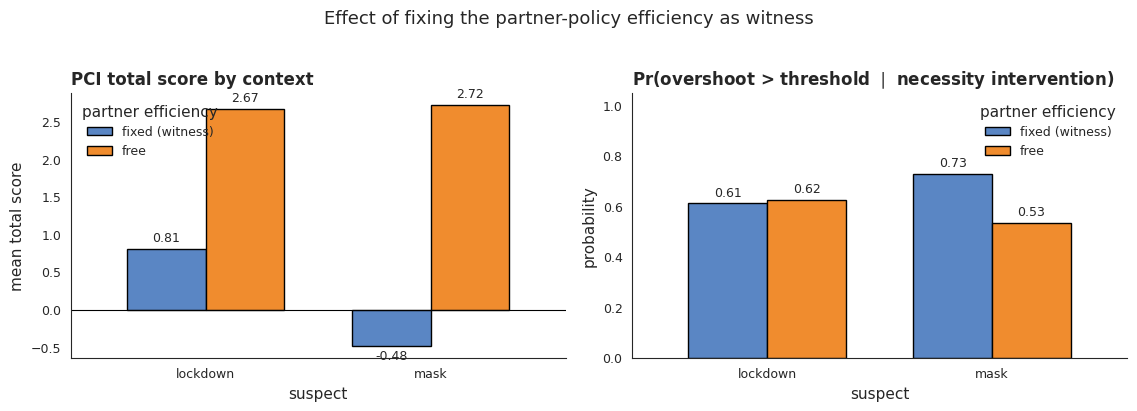

In [13]:
# Figure 5: different-contexts experiment.
# How does fixing the partner-policy efficiency variable as a witness change the
# necessity-side outcome and the resulting PCI score for each suspect?

contexts = [
    ("lockdown", "mask_efficiency"),
    ("mask", "lockdown_efficiency"),
]

ctx_rows = []
for suspect_name, ctx_var in contexts:
    for ctx_label, ctx_flag in [("fixed (witness)", True), ("free", False)]:
        sample = condition_on_interventional_regime(
            results_dictionary=search_results,
            reference_variable_names=[suspect_name, ctx_var],
            antecedent_regimes={suspect_name: True},
            witness_regimes={suspect_name: False, ctx_var: ctx_flag},
        )
        nec_t = sample["regime_necessity"]["overshoot"].detach().cpu().flatten()
        suff_t = sample["regime_sufficiency"]["overshoot"].detach().cpu().flatten()
        keep = ~(torch.isnan(nec_t) | torch.isnan(suff_t))
        n_kept = int(keep.sum().item())
        if n_kept > 0:
            nec_vals = nec_t[keep]
            suff_vals = suff_t[keep]
            pr_too_high_nec = float((nec_vals > overshoot_threshold).float().mean().item())
            mean_nec = float(nec_vals.mean().item())
            mean_suff = float(suff_vals.mean().item())
            scores = abs_diff_score(
                suff_outcomes=sample["regime_sufficiency"]["overshoot"],
                nec_outcomes=sample["regime_necessity"]["overshoot"],
                factual_outcomes=factual_overshoot,
            )
            score_total = float(torch.nanmean(scores["total"]).item())
            score_nec = float(torch.nanmean(scores["nec"]).item())
            score_suff = float(torch.nanmean(scores["suff"]).item())
        else:
            pr_too_high_nec = float("nan")
            mean_nec = float("nan")
            mean_suff = float("nan")
            score_total = float("nan")
            score_nec = float("nan")
            score_suff = float("nan")
        ctx_rows.append(
            {
                "suspect": suspect_name,
                "context_var": ctx_var,
                "context": ctx_label,
                "n_regimes": n_kept,
                "Pr(overshoot>thr | nec)": pr_too_high_nec,
                "mean nec": mean_nec,
                "mean suff": mean_suff,
                "score_nec": score_nec,
                "score_suff": score_suff,
                "score_total": score_total,
            }
        )

ctx_df = pd.DataFrame(ctx_rows)
print(ctx_df.to_string(index=False))

CONTEXT_COLORS = {"fixed (witness)": "#5a86c4", "free": "#f08c2e"}

fig, axs = plt.subplots(1, 2, figsize=(11.5, 4))

score_pivot = ctx_df.pivot(index="suspect", columns="context", values="score_total")
score_pivot = score_pivot[["fixed (witness)", "free"]]
ax_score = score_pivot.plot(
    kind="bar",
    ax=axs[0],
    color=[CONTEXT_COLORS["fixed (witness)"], CONTEXT_COLORS["free"]],
    edgecolor="black",
    width=0.7,
    legend=False,
)
for container in ax_score.containers:
    ax_score.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
axs[0].axhline(0, color="black", linewidth=0.8)
axs[0].set_title("PCI total score by context", loc="left", fontweight="bold")
axs[0].set_ylabel("mean total score")
axs[0].set_xlabel("suspect")
axs[0].tick_params(axis="x", rotation=0)
axs[0].legend(title="partner efficiency", frameon=False)

pr_pivot = ctx_df.pivot(
    index="suspect", columns="context", values="Pr(overshoot>thr | nec)"
)
pr_pivot = pr_pivot[["fixed (witness)", "free"]]
ax_pr = pr_pivot.plot(
    kind="bar",
    ax=axs[1],
    color=[CONTEXT_COLORS["fixed (witness)"], CONTEXT_COLORS["free"]],
    edgecolor="black",
    width=0.7,
    legend=False,
)
for container in ax_pr.containers:
    ax_pr.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
axs[1].set_title(
    r"Pr(overshoot > threshold $\mid$ necessity intervention)",
    loc="left", fontweight="bold",
)
axs[1].set_ylabel("probability")
axs[1].set_xlabel("suspect")
axs[1].set_ylim(0, 1.05)
axs[1].tick_params(axis="x", rotation=0)
axs[1].legend(title="partner efficiency", frameon=False)

fig.suptitle(
    "Effect of fixing the partner-policy efficiency as witness",
    fontsize=13, y=1.02,
)
plt.tight_layout()
sns.despine()

if not smoke_test:
    os.makedirs(fig_dir, exist_ok=True)
    fig.savefig(os.path.join(fig_dir, "sir_contexts.png"))
    print(f"Saved {os.path.join(fig_dir, 'sir_contexts.png')}")

## Conclusions

PCI recovers the qualitative diagnosis of the chirho tutorial — lockdown is the
proximate cause of excessive overshoot, despite both policies appearing similar
under but-for analysis — and expresses it on a continuous, decomposable scale, with
lockdown scoring roughly $2.0\times$ what mask does ($1.54$ vs $0.76$). The
decomposition into necessity and sufficiency contributions is what lets PCI
distinguish suspects whose isolation effects (sufficiency) are similar but whose
removal-under-context effects (necessity) diverge.

The contexts experiment sharpens the picture further. Lockdown registers as a cause
under both context regimes ($0.81$ with mask_efficiency held fixed, $2.67$ with it
free); mask registers as a cause only when its partner is allowed to adapt
($-0.48$ with lockdown_efficiency fixed, $2.72$ with it free). PCI is therefore
able to express not just *which* policy is the dominant cause but *how robustly*
that causal claim holds across counterfactual contexts.

The same machinery applies to any chirho probabilistic program with a continuous
outcome and a tractable enumeration over interventional regimes.